### Arav Ginde - aginde@purdue.edu
### Owen Coss - ocoss@purdue.edu

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

In [7]:
# The College Basketball dataset was chosen by us because of its high real-world relevance in sports analytics. Consisting of over 4000 entries and 24 features and containing strong efficiency metrics, it is sufficient in terms of complexity for EDA.
# 2 ways to do predictive modeling with this dataset:
# 1: REGRESSION - Predicting the number of wins based on team statistics
# 2: CLASSIFICATION - Predicting tournament qualification or team Seed based on the season performance.

In [8]:
df = pd.read_csv('cbb.csv')

print(f"Dataset Shape: {df.shape}") # shape of the dataset
print(df.info())


# Missing values in 'POSTSEASON' and 'SEED' mean the team did not qualify for the tournament
# Fill the missing valeus in 'POSTSEASON' with 'DNQ'(Did Not Qualify), and missing values in 'SEED' with 0
df['POSTSEASON'] = df['POSTSEASON'].fillna('DNQ')
df['SEED'] = df['SEED'].fillna(0)


print("\nMissing values after cleaning:")
print(df.isnull().sum())

df.to_csv('cbb_cleaned.csv', index = False)

Dataset Shape: (4249, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4249 entries, 0 to 4248
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TEAM        4249 non-null   object 
 1   CONF        4249 non-null   object 
 2   G           4249 non-null   int64  
 3   W           4249 non-null   int64  
 4   ADJOE       4249 non-null   float64
 5   ADJDE       4249 non-null   float64
 6   BARTHAG     4249 non-null   float64
 7   EFG_O       4249 non-null   float64
 8   EFG_D       4249 non-null   float64
 9   TOR         4249 non-null   float64
 10  TORD        4249 non-null   float64
 11  ORB         4249 non-null   float64
 12  DRB         4249 non-null   float64
 13  FTR         4249 non-null   float64
 14  FTRD        4249 non-null   float64
 15  2P_O        4249 non-null   float64
 16  2P_D        4249 non-null   float64
 17  3P_O        4249 non-null   float64
 18  3P_D        4249 non-null   float64
 19  A

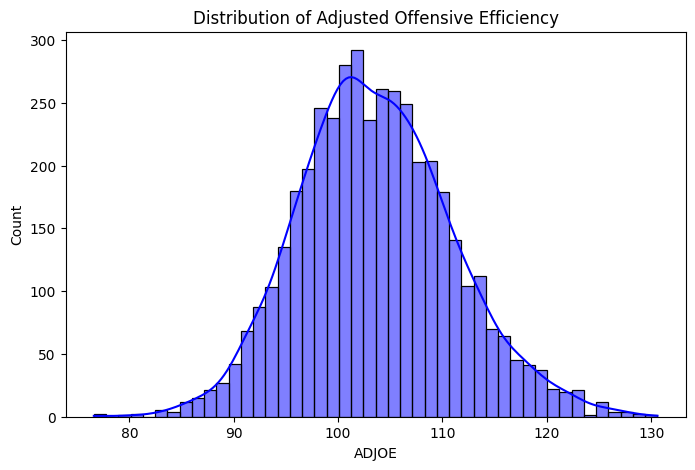

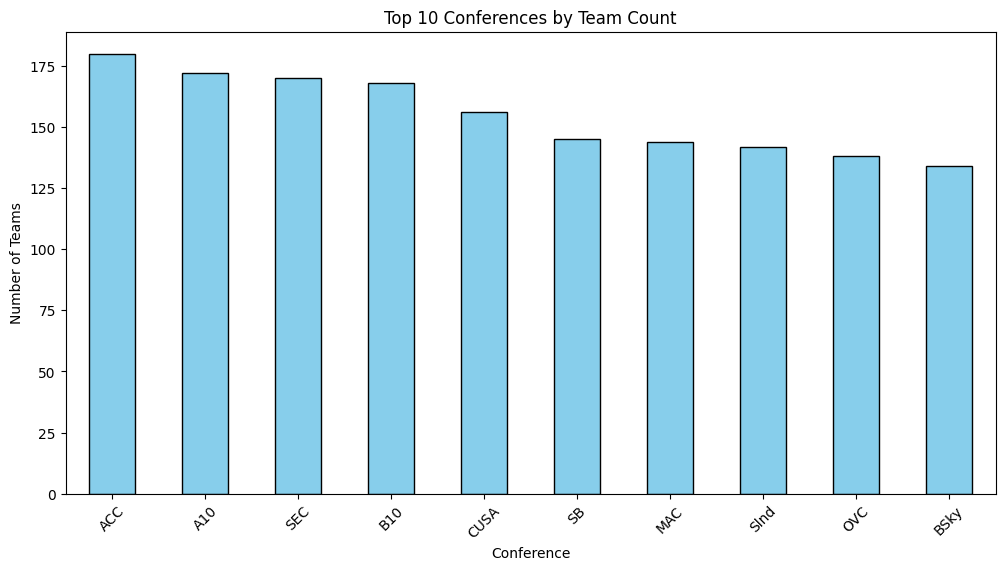

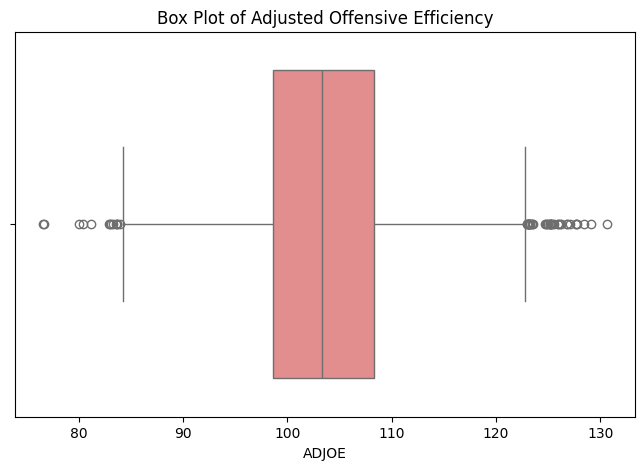

In [20]:
# Exploratory Data Analysis

# Distribution of Adjusted Offensive Efficiency (ADJOE)
plt.figure(figsize = (8, 5))
sns.histplot(df['ADJOE'], kde = True, color = 'blue')
plt.title('Distribution of Adjusted Offensive Efficiency')
plt.show()

plt.figure(figsize=(12, 6))
df['CONF'].value_counts().head(10).plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')
plt.title('Top 10 Conferences by Team Count')
plt.xlabel('Conference')
plt.ylabel('Number of Teams')
plt.xticks(rotation=45)
plt.show()

# Box Plot for checking for outliers in Adjusted Offensive Efficiency
plt.figure(figsize = (8, 5))
sns.boxplot(x = df['ADJOE'], color = 'lightcoral')
plt.title('Box Plot of Adjusted Offensive Efficiency')
plt.xlabel('ADJOE')
plt.show()

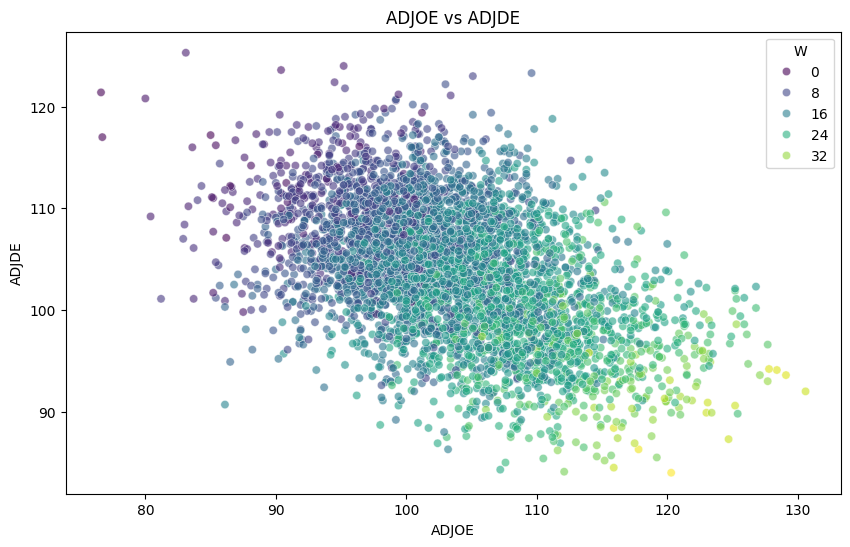

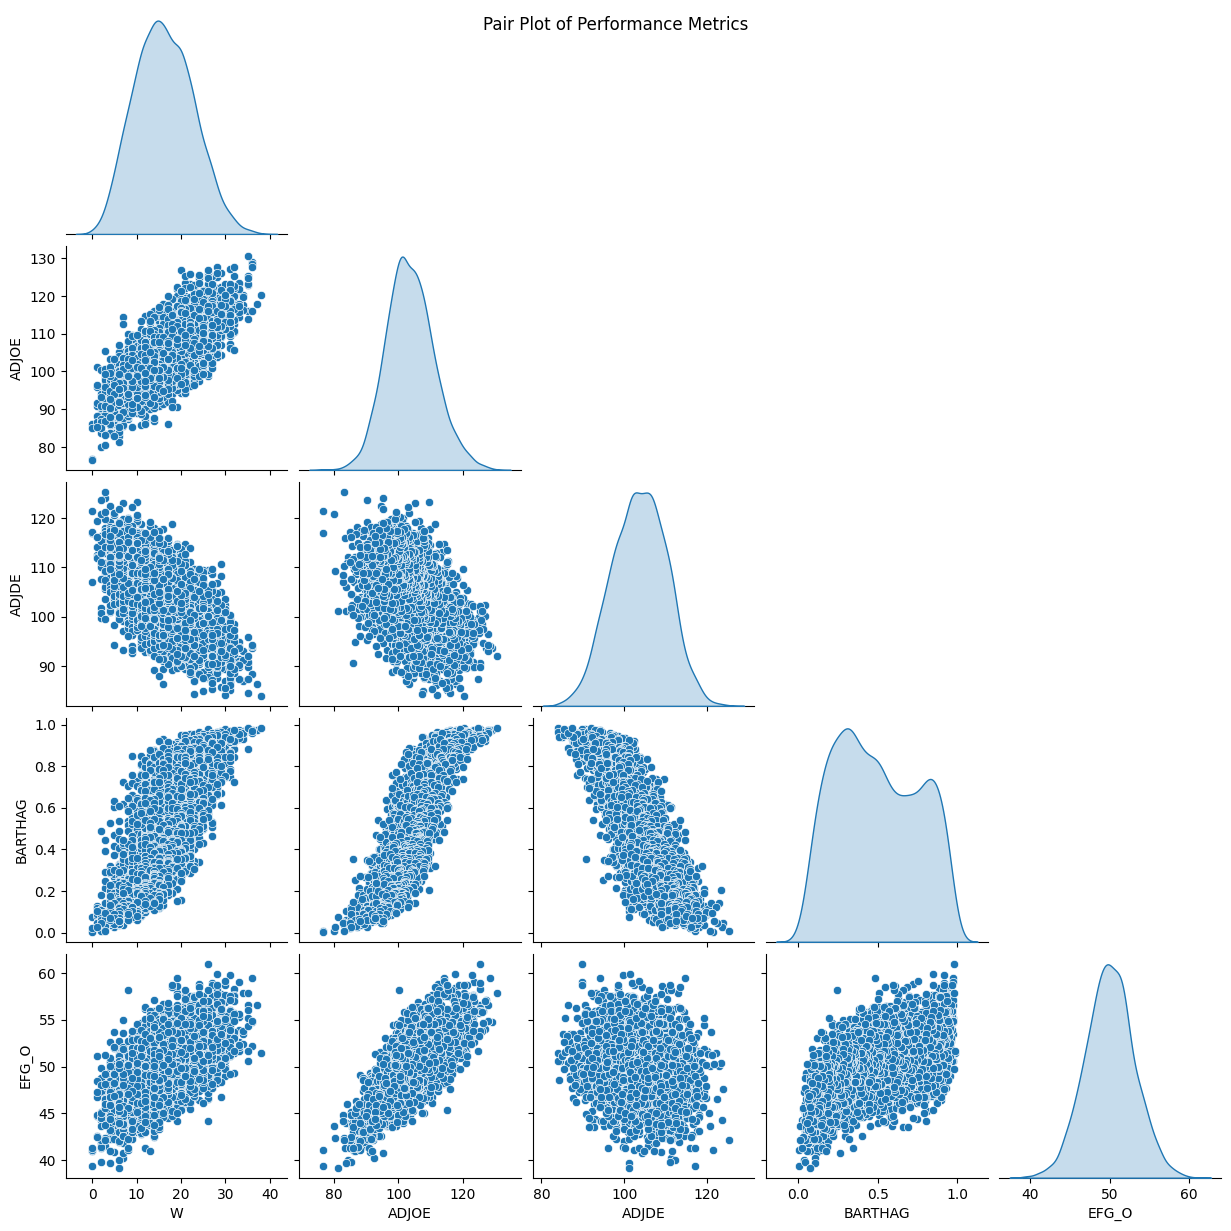

In [24]:
# Relationship between ADJOE and ADJDE colored by the total wins 
plt.figure(figsize=(10, 6))
sns.scatterplot(data = df, x = 'ADJOE', y = 'ADJDE', hue='W', palette = 'viridis', alpha = 0.6)
plt.title('ADJOE vs ADJDE')
plt.show()

# pair plot to visualize the relationships between these key metrics below.
key_metrics = ['W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O']
sns.pairplot(df[key_metrics], corner = True, diag_kind = 'kde')
plt.suptitle('Pair Plot of Performance Metrics')
plt.show()

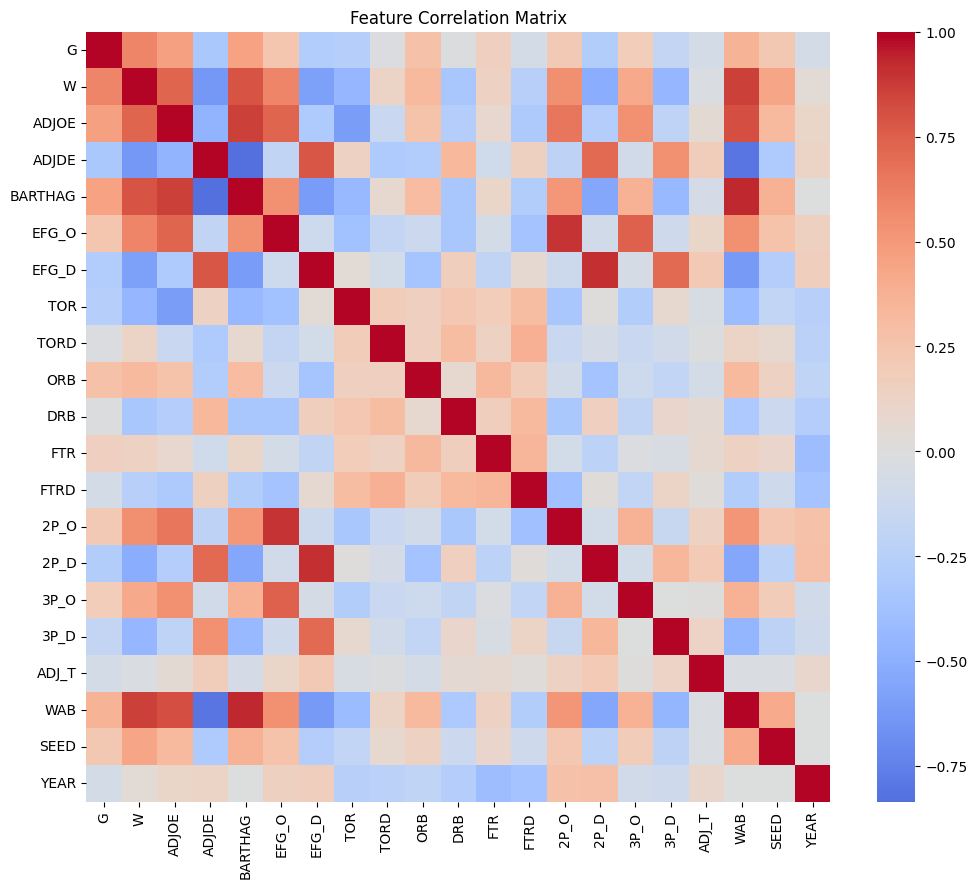

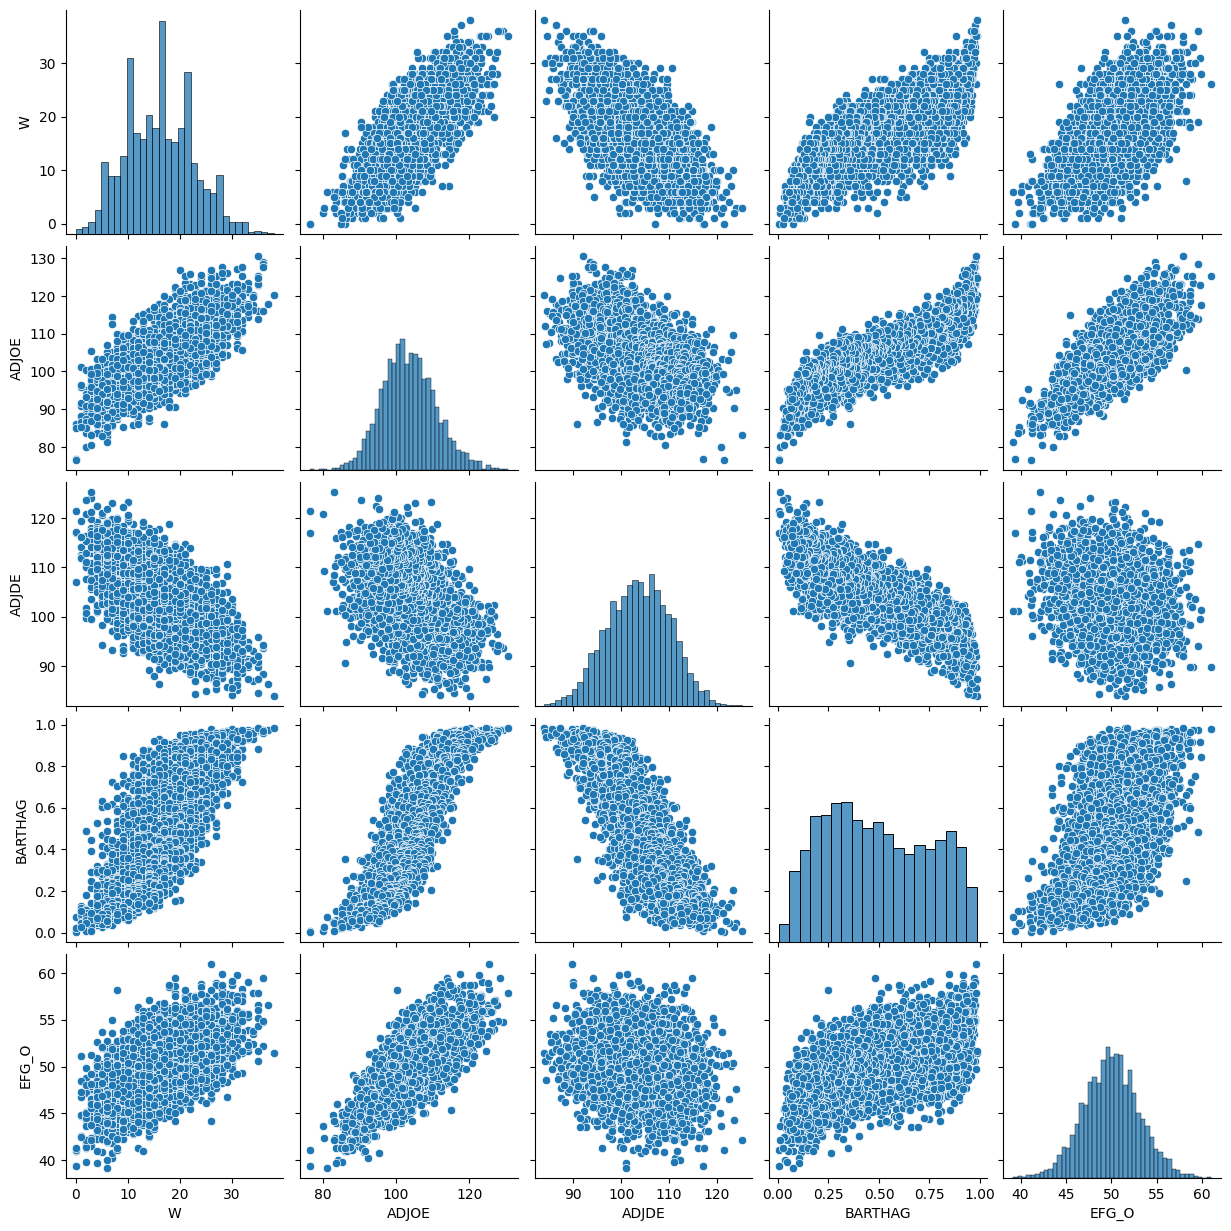

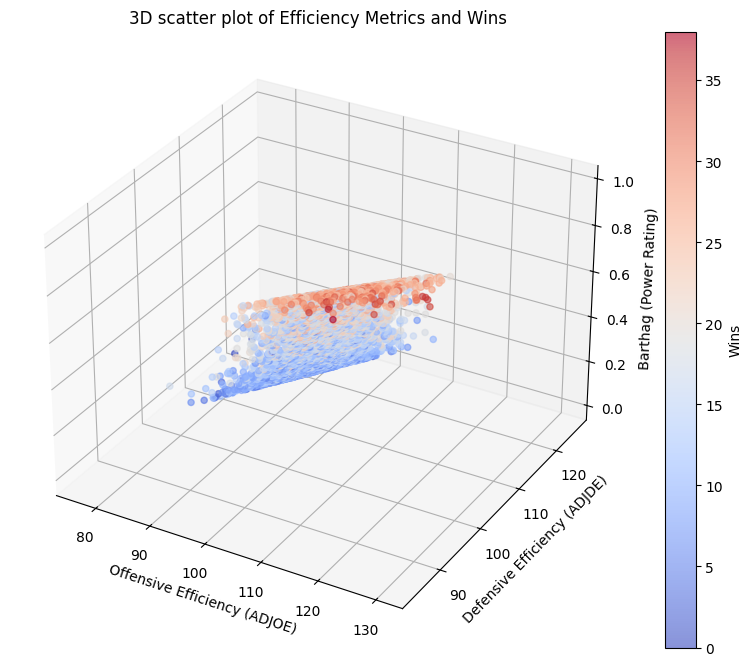

In [29]:
# Multivariate Analysis

# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot = False, cmap = 'coolwarm', center = 0)
plt.title('Feature Correlation Matrix')
plt.show()

# Pairplot for a subset of critical metrics
subsetCols = ['W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O']
sns.pairplot(df[subsetCols])
plt.show()

# 3D scatter plot of offensive efficiency vs defensive efficiency vs power rating 
figure = plt.figure(figsize = (10, 8))
axis = figure.add_subplot(111, projection = '3d')

scatter = axis.scatter(df['ADJOE'], df['ADJDE'], df['BARTHAG'], c = df['W'], cmap = 'coolwarm', alpha = 0.6)

axis.set_xlabel('Offensive Efficiency (ADJOE)')
axis.set_ylabel('Defensive Efficiency (ADJDE)')
axis.set_zlabel('Barthag (Power Rating)')
plt.colorbar(scatter, label = 'Wins')
plt.title('3D scatter plot of Efficiency Metrics and Wins')
plt.show()



In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [13]:
# Feature Engineering

# Goal to predict number of wins (W), so we drop non-predictive columns like 'TEAM' and the 'W' column since that's what we are predicting.
X = df.drop(columns = ['TEAM', 'W', 'POSTSEASON', 'SEED', 'YEAR'])
y = df['W']

# the only other categorical column is "CONF" (conference) at index 0 after dropping the "TEAM" column
# other columns are numerical

categoricalFeatures = ['CONF'] 
numericalFeatures = X.columns.drop('CONF')

# column transformer

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), categoricalFeatures), ('scaler', StandardScaler(), numericalFeatures)], remainder = 'passthrough')
X = np.array(ct.fit_transform(X))

print(f"Shape of transformed features: {X.shape}")

Shape of transformed features: (4249, 53)


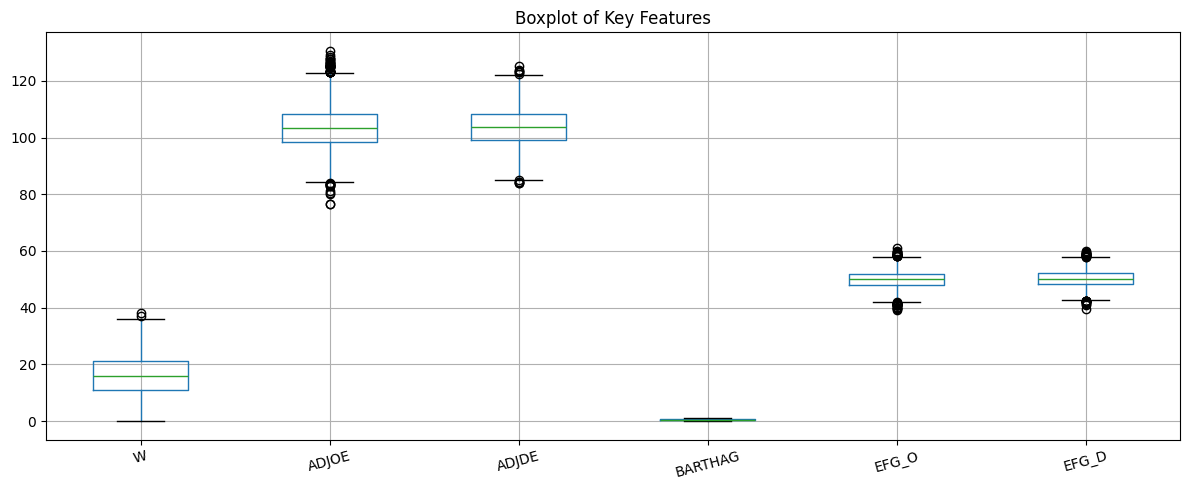

In [14]:
# box plots to visualize distributions and flag potential outliers
checkCols = ['W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D']

plt.figure(figsize=(12, 5))
df[checkCols].boxplot()
plt.title('Boxplot of Key Features')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

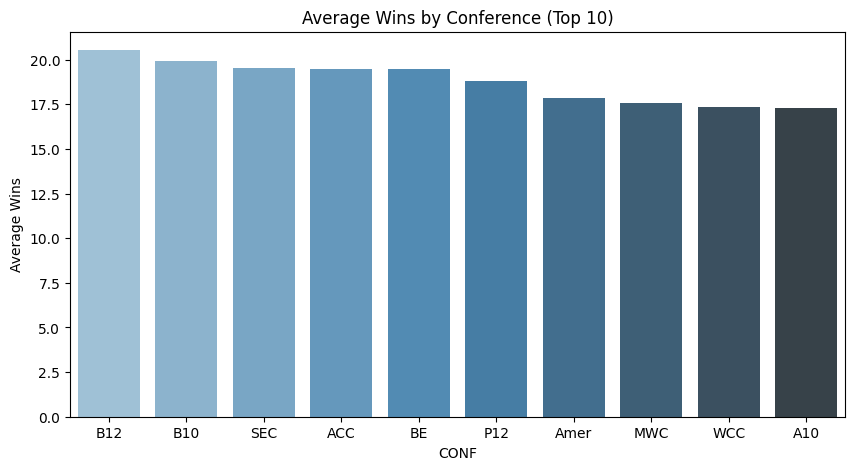

In [15]:
# bar chart for average wins per conference (top 10)
confWins = df.groupby('CONF')['W'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=confWins, x='CONF', y='W', hue='CONF', palette='Blues_d', legend=False)
plt.title('Average Wins by Conference (Top 10)')
plt.ylabel('Average Wins')
plt.show()

In [16]:
# IQR outlier report
print("Outlier report (IQR method):")
for col in checkCols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {n_out} outliers ({n_out / len(df) * 100:.1f}%)")

# Outliers represent genuine extreme performances (e.g. a 0-win or 38-win season)
# Retaining them preserves real-world variability in the dataset

Outlier report (IQR method):
  W: 2 outliers (0.0%)
  ADJOE: 50 outliers (1.2%)
  ADJDE: 11 outliers (0.3%)
  BARTHAG: 0 outliers (0.0%)
  EFG_O: 45 outliers (1.1%)
  EFG_D: 30 outliers (0.7%)


For model building, we split the preprocessed data into training (80%) and testing (20%) sets, then train two regression models to predict total wins. Linear Regression is a baseline, and Random Forest Regressor is a more complex model

In [17]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nModels trained successfully.")


Training samples: 3399
Testing samples:  850

Models trained successfully.


Model                        R²      MAE     RMSE
--------------------------------------------------
Linear Regression 0.9693532141472978 0.9280781305865335 1.164564017624238
Random Forest 0.9162202375618593 1.5286470588235292 1.9254864320477567


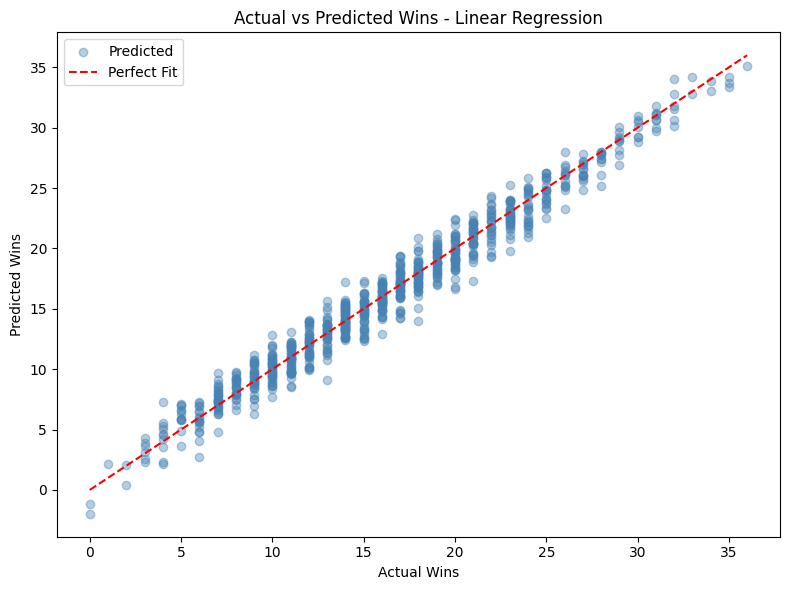

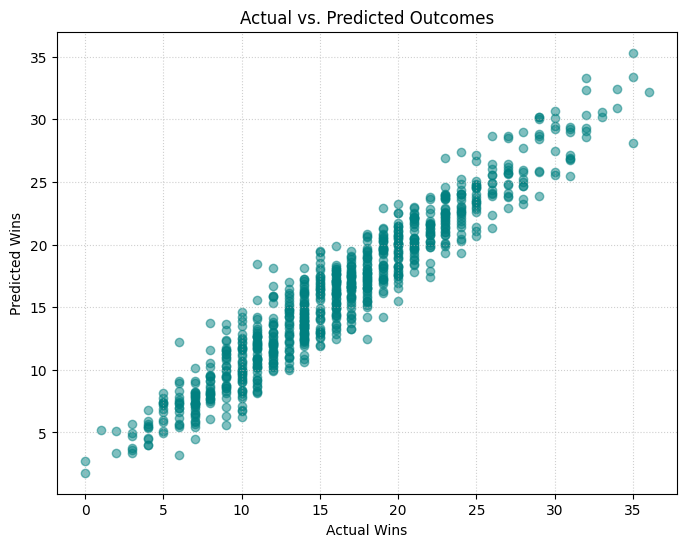

In [32]:
# Metrics for both models
models_eval = {'Linear Regression': y_pred_lr,'Random Forest': y_pred_rf}

print(f"{'Model':<22} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 50)
for name, y_pred in models_eval.items():
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name} {r2} {mae} {rmse}")

# Actual vs Predicted with Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect Fit')
plt.xlabel('Actual Wins')
plt.ylabel('Predicted Wins')
plt.title('Actual vs Predicted Wins - Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred, alpha = 0.5, color = 'teal')


plt.xlabel('Actual Wins')
plt.ylabel('Predicted Wins')
plt.title('Actual vs. Predicted Outcomes')
plt.grid(True, linestyle = ':', alpha = 0.6)
plt.show()

 n_estimators max_depth  min_samples_split     R2    MAE   RMSE
          200      None                  2 0.9168 1.5185 1.9182
          100      None                  2 0.9162 1.5286 1.9255
          200      None                  5 0.9161 1.5252 1.9268
          100      None                  5 0.9156 1.5350 1.9326
          200        10                  5 0.9087 1.5963 2.0103
          100        10                  2 0.9083 1.6036 2.0146
          100        10                  5 0.9083 1.6044 2.0149
          200        10                  2 0.9083 1.5962 2.0139

Best config — n_estimators: 200, max_depth: None, min_samples_split: 2


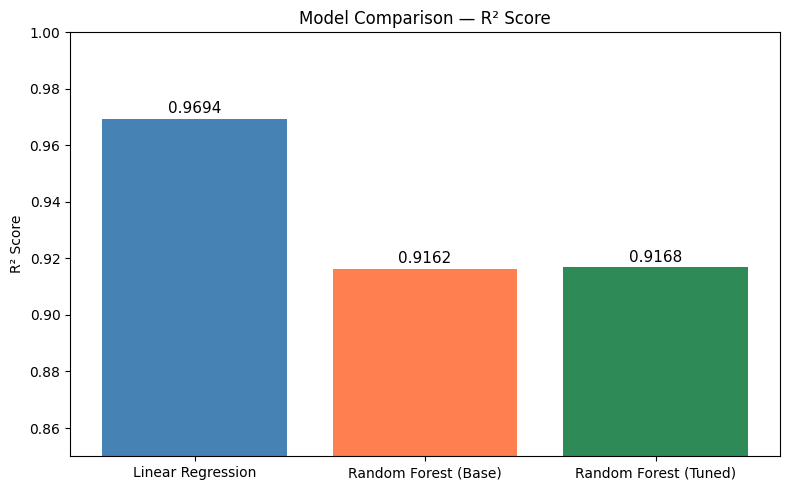

In [19]:
# Manual hyperparameter search for Random Forest 
tuningResults = []

for n_est in [100, 200]:
    for max_d in [None, 10]:
        for mss in [2, 5]:
            rfTune = RandomForestRegressor(
                n_estimators=n_est, max_depth=max_d,
                min_samples_split=mss, random_state=42
            )
            rfTune.fit(X_train, y_train)
            yp = rfTune.predict(X_test)
            tuningResults.append({
                'n_estimators': n_est,
                'max_depth': str(max_d),
                'min_samples_split': mss,
                'R2':   round(r2_score(y_test, yp), 4),
                'MAE':  round(mean_absolute_error(y_test, yp), 4),
                'RMSE': round(np.sqrt(mean_squared_error(y_test, yp)), 4),
                'model': rfTune,
                'preds': yp
            })

tuningDf = pd.DataFrame(tuningResults).drop(columns=['model', 'preds'])
print(tuningDf.sort_values('R2', ascending=False).to_string(index=False))

# Best tuned configuration
bestResult = max(tuningResults, key=lambda x: x['R2'])
y_pred_tuned = bestResult['preds']

print(f"\nBest config — n_estimators: {bestResult['n_estimators']}, "
      f"max_depth: {bestResult['max_depth']}, "
      f"min_samples_split: {bestResult['min_samples_split']}")

# Final comparison bar chart
finalModels = ['Linear Regression', 'Random Forest (Base)', 'Random Forest (Tuned)']
r2Scores    = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_tuned)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(finalModels, r2Scores, color=['steelblue', 'coral', 'seagreen'])
plt.ylim(0.85, 1.0)
plt.ylabel('R² Score')
plt.title('Model Comparison — R² Score')
for bar, score in zip(bars, r2Scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### Conclusions
- Linear Regression had the highest R^2 (~0.97), outperforming the Random Forest. This suggests that wins have strong linear relationships with the metrics in this dataset (particularly ADJOE, ADJDE, and BARTHAG).
- Random Forest captured non-linear patterns but showed no improvement over the linear model, and was more sensitive to hyperparameter choice.
- Hyperparameter tuning verified the base RF configuration was already very optimal for this data.